In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from Lib_trust_region import mRC_SR1
from Lib_kmeans_softmin import crear_objetivo_kmeans_softmin, asignaciones_duras

In [2]:
#Importa los datos sobre los cuales se van a trabajar 
#Para este ejemplo se va a usar 
ruta = "iris/iris.data"

columnas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(ruta, header=None, names=columnas) 

#Estandarizamos los datos (que esten en la misma escala)
X = df.iloc[:, :-1].values 


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# 4. Configuración de Soft K-Means
k = 3          # Sabemos que Iris tiene 3 especies (Setosa, Versicolor, Virginica)
d = X.shape[1] # 4 características por flor
tau = 0.5      # Parámetro de suavizado (temperatura)

#print(d)
f_objetivo = crear_objetivo_kmeans_softmin(X_scaled, k, tau, promedio=True)
  

In [4]:
np.random.seed(42)
W0 = np.random.randn(k, d) # Inicializamos aleatoriamente
w0_flat = W0.flatten()

w_opt_flat, iteraciones = mRC_SR1(f=f_objetivo, x0=w0_flat, maxDelta=10.0, imax=200, tol=1e-4, delta=1.0, dogLeg=True)

print("Happy iteration in ", iteraciones)
# Reconstruimos los centroides 
W_opt = w_opt_flat.reshape((k, d)) 

print("Los centros son: ")
print(W_opt)
print("El valor mínimo es: ")
print(f_objetivo(W_opt))
labels_pred = asignaciones_duras(X_scaled, W_opt)
#print("Las etiquetas son: ")
#print(labels_pred)

#print(len(labels_pred))

Happy iteration in  11
Los centros son: 
[[ 1.03932084  0.02328468  0.95159319  0.97214116]
 [-0.0256124  -0.86397753  0.34930492  0.28081778]
 [-1.0113411   0.85117392 -1.30303147 -1.25396794]]
El valor mínimo es: 
0.9675835877122959


In [5]:
#Comparacion usando el punto de cauchy
w_opt_flat_cauch,iteraciones = mRC_SR1(f=f_objetivo, x0=w0_flat, maxDelta=10.0, imax=200, tol=1e-4, delta=1.0, dogLeg=False)

print("Happy iteration in ", iteraciones)
# Reconstruimos los centroides 
W_opt_cauch = w_opt_flat_cauch.reshape((k, d)) 

print("Los centros son: ")
print(W_opt_cauch)
print("El valor mínimo es: ")
print(f_objetivo(W_opt_cauch))
labels_pred_cauch = asignaciones_duras(X_scaled, W_opt_cauch)
#print("Las etiquetas son: ")
#print(labels_pred_cauch)

Happy iteration in  8
Los centros son: 
[[ 1.03970772  0.02350669  0.95176843  0.9722469 ]
 [-0.02537311 -0.8639151   0.34937746  0.28086882]
 [-1.01138199  0.8512268  -1.30298596 -1.25393352]]
El valor mínimo es: 
0.9675835801783037


In [6]:
#Analisis de convergencia



historial_iteraciones = []
historial_costos = []

historial_iteraciones_cauchy = []
historial_costos_cauchy = []

for i in range(10):
    np.random.seed(i*10)
    W0_random = np.random.randn(k, d)
    w0_flat_random = W0_random.flatten()
    
    w_opt, iteraciones = mRC_SR1(
        f=f_objetivo, x0=w0_flat_random, 
        maxDelta=10.0, imax=200, tol=1e-4, delta=1.0, dogLeg=True
    )
    
    # Evaluamos el costo (la función objetivo) en el punto final encontrado
    costo_final = f_objetivo(w_opt)
    
    historial_iteraciones.append(iteraciones)
    historial_costos.append(costo_final)
    
    w_opt, iteraciones = mRC_SR1(
        f=f_objetivo, x0=w0_flat_random, 
        maxDelta=10.0, imax=200, tol=1e-4, delta=1.0, dogLeg=False
    )
    
    costo_final = f_objetivo(w_opt)
    
    historial_iteraciones_cauchy.append(iteraciones)
    historial_costos_cauchy.append(costo_final)

# Calcular el mejor costo encontrado en todas las ejecuciones
optimal_cost = min(historial_costos + historial_costos_cauchy)

df_convergencia = pd.DataFrame({
    'Ejecución': range(1, 11),
    'Iteraciones_DogLeg': historial_iteraciones,
    'Costo_Final_DogLeg': historial_costos,
    'Iteraciones_Cauchy': historial_iteraciones_cauchy,
    'Costo_Final_Cauchy': historial_costos_cauchy
})


df_convergencia['Error_DogLeg']  = df_convergencia['Costo_Final_DogLeg']  - optimal_cost
df_convergencia['Error_Cauchy']  = df_convergencia['Costo_Final_Cauchy'] - optimal_cost

promedios = {
    'Ejecución': 'Promedio',
    'Iteraciones_DogLeg': np.mean(historial_iteraciones),
    'Costo_Final_DogLeg': np.mean(historial_costos),
    'Iteraciones_Cauchy': np.mean(historial_iteraciones_cauchy),
    'Costo_Final_Cauchy': np.mean(historial_costos_cauchy),
    'Error_DogLeg': np.mean([c - optimal_cost for c in historial_costos]),
    'Error_Cauchy': np.mean([c - optimal_cost for c in historial_costos_cauchy])
}

df_convergencia = pd.concat([df_convergencia, pd.DataFrame([promedios])], ignore_index=True)

print("Tabla de convergencia (10 inicializaciones aleatorias):")
display(df_convergencia.round(6))
    


Tabla de convergencia (10 inicializaciones aleatorias):


,Ejecución,Iteraciones_DogLeg,Costo_Final_DogLeg,Iteraciones_Cauchy,Costo_Final_Cauchy,Error_DogLeg,Error_Cauchy
0,1,21.0,0.967584,10.0,0.967584,0.0,0.0
1,2,13.0,0.967584,9.0,0.967584,0.0,0.0
2,3,29.0,0.967584,47.0,0.967584,0.0,0.0
3,4,25.0,0.967584,32.0,0.967584,0.0,0.0
4,5,27.0,0.967584,29.0,0.967584,0.0,0.0
5,6,8.0,0.967584,13.0,0.967584,0.0,0.0
6,7,14.0,0.967584,12.0,0.967584,0.0,0.0
7,8,21.0,0.967584,13.0,0.967584,0.0,0.0
8,9,10.0,0.967584,10.0,0.967584,0.0,0.0
9,10,38.0,0.967584,39.0,0.967584,0.0,0.0


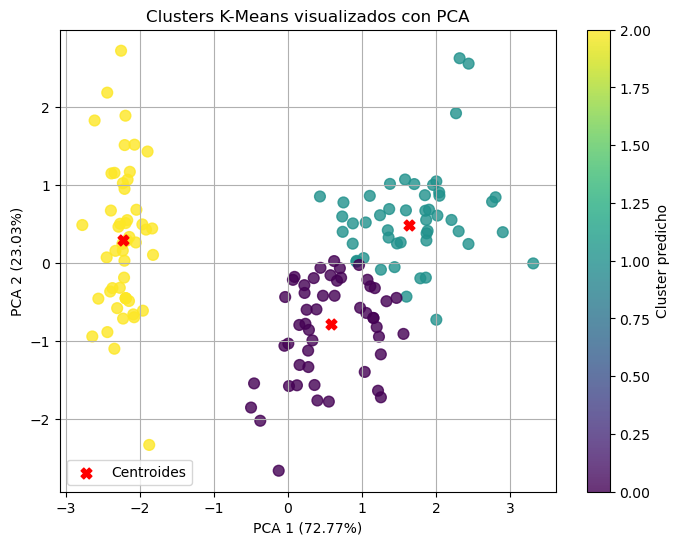

In [8]:
#Graficas usando PCA para reducir a dimension 2

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
W_opt_pca = pca.transform(W_opt)

df_pca = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': labels_pred,
    'Especie Real': df['species']
})

plt.figure(figsize=(8, 6))

# Graficar puntos coloreados por cluster predicho
scatter = plt.scatter(
    df_pca['PCA1'],
    df_pca['PCA2'],
    c=df_pca['Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.8
)

# Graficar centroides transformados con PCA
plt.scatter(
    W_opt_pca[:, 0],
    W_opt_pca[:, 1],
    color='red',
    marker='X',
    s=60,
    label='Centroides'
)

plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.title('Clusters K-Means visualizados con PCA')
plt.legend()
plt.colorbar(scatter, label='Cluster predicho')
plt.grid(True)
plt.show()

In [9]:
df_eval = pd.DataFrame({
    'Especie Real': df['species'],
    'Cluster Predicho': labels_pred
})

tabla_contingencia = pd.crosstab(df_eval['Especie Real'], df_eval['Cluster Predicho'])

print("Tabla de Contingencia (Especies Reales vs Clusters):")
display(tabla_contingencia)

# Crear un diccionario que asigna cada cluster a la especie más frecuente
mapa_clusters = tabla_contingencia.idxmax(axis=0).to_dict()

print("Mapa de clusters a especies:")
print(mapa_clusters)

# Convertir los clusters numéricos a nombres de especies
df_eval['Especie Predicha'] = df_eval['Cluster Predicho'].map(mapa_clusters)

# Nueva tabla consistente: nombre vs nombre
tabla_consistente = pd.crosstab(
    df_eval['Especie Real'],
    df_eval['Especie Predicha']
)

print("Tabla de Contingencia Consistente:")
display(tabla_consistente)

Tabla de Contingencia (Especies Reales vs Clusters):


Cluster Predicho,0,1,2
Especie Real,,,
Iris-setosa,0,0,50
Iris-versicolor,38,12,0
Iris-virginica,13,37,0


Mapa de clusters a especies:
{0: 'Iris-versicolor', 1: 'Iris-virginica', 2: 'Iris-setosa'}
Tabla de Contingencia Consistente:


Especie Predicha,Iris-setosa,Iris-versicolor,Iris-virginica
Especie Real,,,
Iris-setosa,50,0,0
Iris-versicolor,0,38,12
Iris-virginica,0,13,37


In [10]:
#Acuracy
aciertos = (df_eval['Especie Real'] == df_eval['Especie Predicha']).sum()
total = len(df_eval)
accuracy = aciertos / total

print(f"Aciertos: {aciertos} de {total}")
print(f"Accuracy: {accuracy:.2%}")

Aciertos: 125 de 150
Accuracy: 83.33%
